In [1]:
import pandas
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pandas.read_excel('ATIVA-ER_EN_April_13_2026.xlsx')
print(df.shape)
df = df[1:]
print(df.head(5))

(74, 95)
  UserLanguage Diagnosis Diagnosis_8_TEXT ASD_01 ASD_02 ADHD_01   ADHD_02  \
1           EN       NaN              NaN    NaN    NaN     NaN       NaN   
2           EN      ADHD              NaN    NaN    NaN     18+  Combined   
3           EN       NaN              NaN    NaN    NaN     NaN       NaN   
4           EN       NaN              NaN    NaN    NaN     NaN       NaN   
5           EN       NaN              NaN    NaN    NaN     NaN       NaN   

    ADHD_03 ID_01 ID_02  ...        AA embodied_include? If yes, why?.1  \
1       NaN   NaN   NaN  ...  Neither agree nor disagree            NaN   
2  Moderate   NaN   NaN  ...           Strongly disagree            NaN   
3       NaN   NaN   NaN  ...           Strongly disagree            NaN   
4       NaN   NaN   NaN  ...          Partially disagree            NaN   
5       NaN   NaN   NaN  ...  Neither agree nor disagree            NaN   

  If yes, why?_5_TEXT                                     If not, why?.1  \
1

In [3]:
#Remove incomplete responses

# keep_series = df.isnull().apply(lambda row: row.value_counts(), axis=1)
# keep_series = keep_series.apply(lambda row: int(row[True]) if (True in row) and (not np.isnan(row[True])) else 0, axis=1)
# keep_series = keep_series.apply(lambda x: False if x > 70 else True)
# df = df[keep_series]
# print(df.shape)

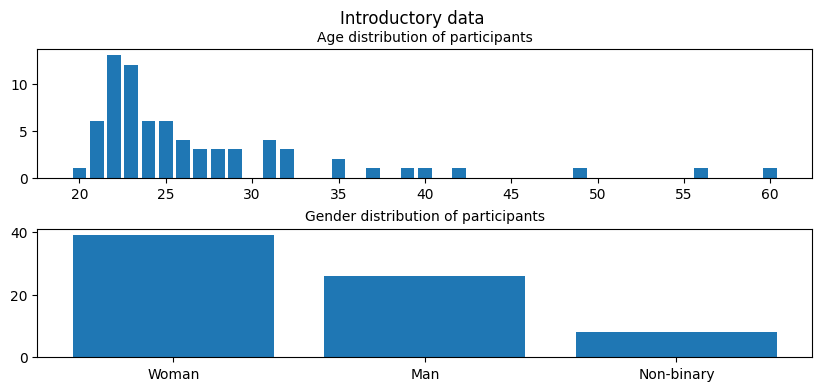

In [4]:
# print(df.columns)
age_counts = df['Age'].value_counts().sort_index()
gender_counts = df['Gender'].value_counts()

# fake data
fs = 10  # fontsize
fig, axs = plt.subplots(nrows=2, figsize=(10, 4))

axs[0].bar(age_counts.index, age_counts)
axs[0].set_title('Age distribution of participants', fontsize=fs)

axs[1].bar(gender_counts.index, gender_counts)
axs[1].set_title('Gender distribution of participants', fontsize=fs)

fig.suptitle("Introductory data")
fig.subplots_adjust(hspace=0.4)
plt.show()

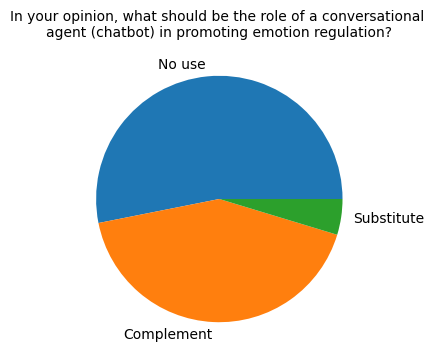

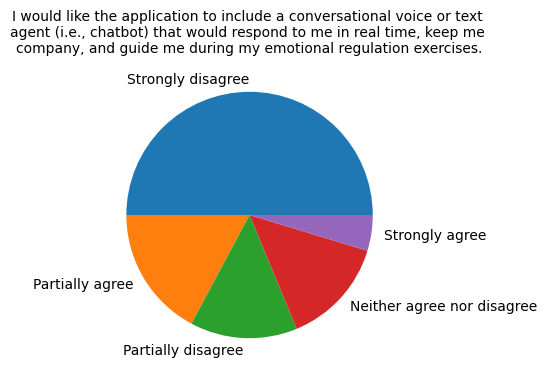

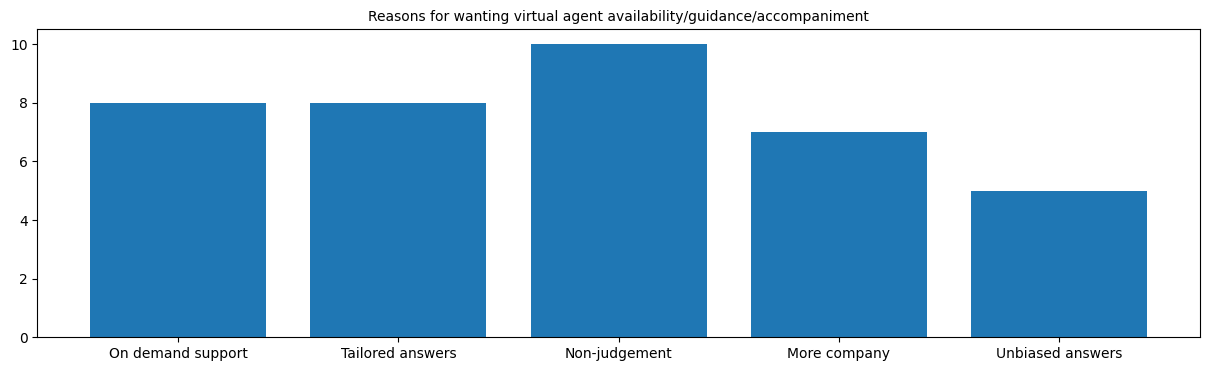

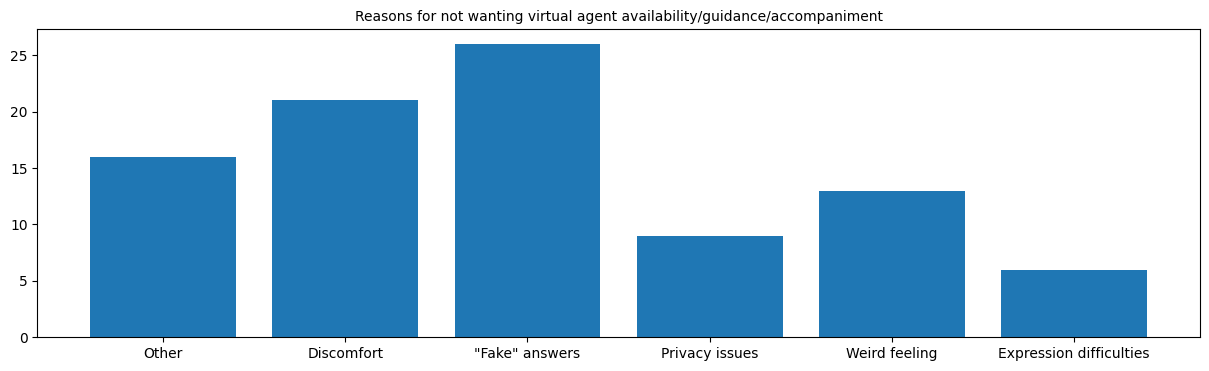

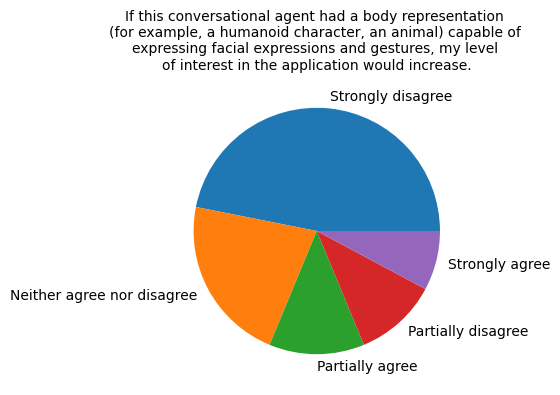

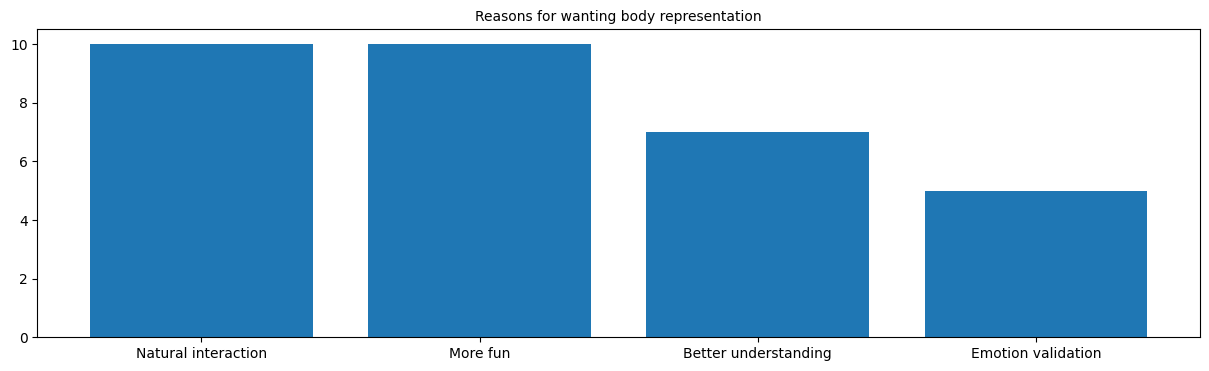

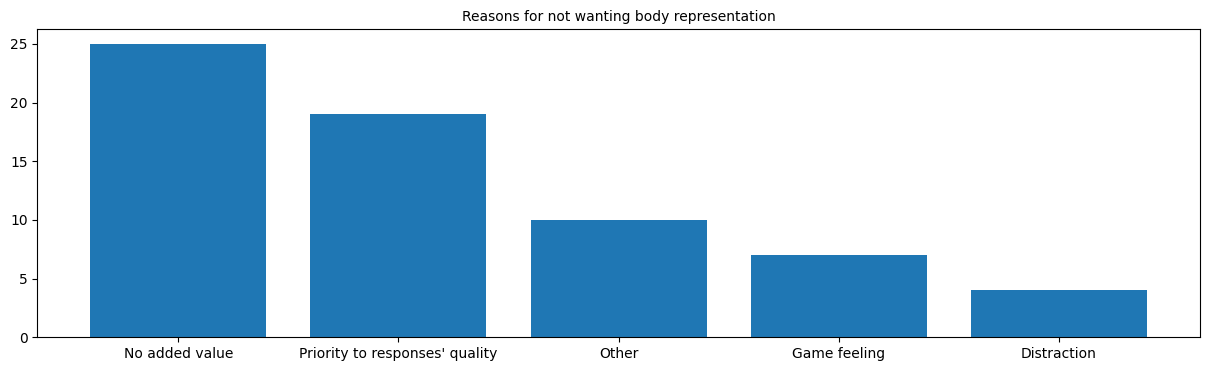

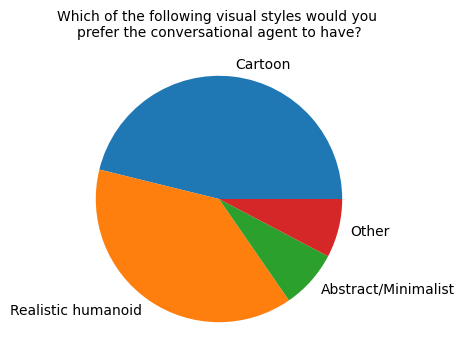

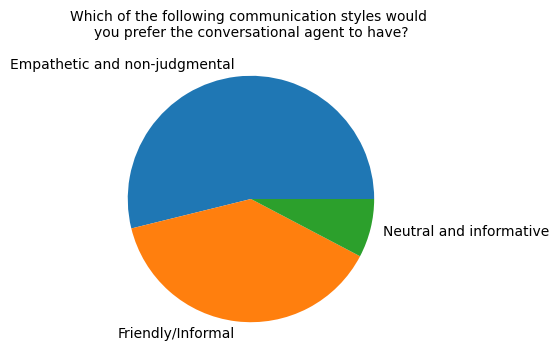

In [5]:
aa_role = {
    'role': ('AA_role', 'pie', 'In your opinion, what should be the role of a conversational \nagent (chatbot) in promoting emotion regulation?'),
    'include': ('AA_include?', 'pie', 'I would like the application to include a conversational voice or text \nagent (i.e., chatbot) that would respond to me in real time, keep me \ncompany, and guide me during my emotional regulation exercises.'),
    'yes_why': ('If yes, why?', 'bar', 'Reasons for wanting virtual agent availability/guidance/accompaniment'),
    #'yes_why_text': 'If yes, why?_6_TEXT',
    'no_why': ('If not, why?', 'bar', 'Reasons for not wanting virtual agent availability/guidance/accompaniment'),
    # 'no_why_text': 'If not, why?_6_TEXT',
 }

aa_embodied = {
    'body_likert': ('AA embodied_include?', 'pie', 'If this conversational agent had a body representation \n(for example, a humanoid character, an animal) capable of \nexpressing facial expressions and gestures, my level \nof interest in the application would increase.'),
    'yes_why': ('If yes, why?.1', 'bar', 'Reasons for wanting body representation'),
    #'yes_why_text': 'If yes, why?_5_TEXT',
    'no_why': ('If not, why?.1', 'bar', 'Reasons for not wanting body representation'),
    # 'no_why_text': 'If not, why?_5_TEXT',
 }

appearance = {
    'app': ('Appearance', 'pie', 'Which of the following visual styles would you \nprefer the conversational agent to have?'),
    #'app_text': 'Appearance_5_TEXT',
}

comm_style = {
    'comm': ('Communication style.1', 'pie', 'Which of the following communication styles would \nyou prefer the conversational agent to have?'),
    #'comm_text': 'Communication style_6_TEXT',
}


questions_array = [aa_role, aa_embodied, appearance, comm_style]
for question in questions_array:
    for figure in question.keys():
        fig, ax = plt.subplots(figsize=(15, 4))
        data = df[question[figure][0]].value_counts()

        if question[figure][1] == 'bar':
            # print(question[figure][2])
            # print(question[figure][1])
            # print(data.index)
            # print(data)
            data_dict = {}
            for entry in data.index:
                keys = entry.split(',')
                for key in keys:
                    if not (key in data_dict.keys()):
                        data_dict[key] = 0
            # print(data_dict)

            for entry in df[question[figure][0]]:
                if type(entry) == str:
                    keys = entry.split(',')
                    for key in keys:
                        data_dict[key] += 1

            ax.bar(data_dict.keys(), data_dict.values())
        elif question[figure][1] == 'pie':
            ax.pie(data, labels=data.index)
        ax.set_title(question[figure][2], fontsize=10)

        # fig.suptitle("Introductory data")
        # fig.subplots_adjust(hspace=0.4)
        plt.show()